By the end of the lesson, all learners will be able to (minimum expected from everyone) :

- Recall the working of Long Short Term Memory.
- Understand the forward and Backward propagation in LSTM

To start this lesson **all students must be aware** of the following concepts:

- Sequential Networks
- Workings of Recurrent Neural Networks
- Activation Functions like: $Tanh, ReLU, Sigmoid$
- Workings of LSTM
- Backpropagation through time in RNN

The figure below is the LSTM cell. We have already discussed the different gates in LSTM, different states in LSTM, and their uses in the previous chapter. Here, in this chapter, we will be going through forward propagation and backpropagation in LSTM.

<div align="center">

[![lstm-cell.png](https://i.postimg.cc/ryBJ7tyX/lstm-cell.png)](https://postimg.cc/SjGCMRzD)

*figure: Single LSTM Cell*
</div>

## Forward Propagation in LSTM

Input gate : $i_t$ = $sigmoid(U_i x_t + W_i  h_{t-1} + b_i)$

- $U_i$ is the input-to-hidden layer weights of the input gate.

- $W_i$ is the hidden-to-hidden layer weights of the input gate.

- $b_i$ is the bias of the input gate.

Forget gate : $f_t$ = $ sigmoid(U_f  x_t + W_f h_{t-1} + b_f)$

- $U_f$ is input-to-hidden layer weights of the forget gate.

- $W_f$ is hidden-to-hidden layer weights of the forget gate.

- $b_f$ is the bias of forget gate.

Output gate : $o_t$ = $ sigmoid(U_o  x_t + W_o h_{t-1} + b_o)$

- $U_o$ is the input-to-hidden layer weights of the output gate.

- $W_o$ is the hidden-to-hidden layer weights of the output gate.

- $b_f$ is the bias of the output gate.

Candidate State : $g_t$ = $tanh(U_g x_t + W_g h_{t-1} + b_g)$

- $U_g$ is the input-to-hidden layer weights of the Candidate State.

- $W_g$ is hidden-to-hidden layer weights of the Candidate State.

- $b_g$ is the bias of the Candidate State.

Cell State : $c_t$ = $f_t C_{t-1} + i_t g_t$

Hidden State : $h_t$ = $o_t tanh(c_t)$

Output : $\widehat y_t$ = $softmax(V h_t)$

Loss : $L_t$ = $-y_t log (\widehat y_t)$

Total Loss is the sum of loss at all time-steps : $L$ = $\sum_{j=0}^T L_j$




## Backpropagation through time

For backpropagation, we need to compute partial derivatives of loss with respect to the weight parameters.

$$ \frac{\partial \mathcal{L}}{\partial U_i},  \frac{\partial \mathcal{L}}{\partial U_f}, \frac{\partial \mathcal{L}}{\partial U_o},  \frac{\partial \mathcal{L}}{\partial U_g} $$



$$ \frac{\partial \mathcal{L}}{\partial W_i},  \frac{\partial \mathcal{L}}{\partial W_f}, \frac{\partial \mathcal{L}}{\partial W_o},  \frac{\partial \mathcal{L}}{\partial W_g} $$



$$ \frac{\partial \mathcal{L}}{\partial V} $$


We need to calculate gradients for all these weights. For that first, we need to calculate the gradients with respect to gates and states.





## Gradients of Loss with respect to states.

In LSTM we have three different states, Candidate state($g_t$) ,Cell state($c_t$), Hidden State ($h_t$). We need to compute gradients of Loss with respect to these three states.

First, let us recall the derivative of Sigmoid and tanh function.

-- $sigmoid^`(x) = sigmoid(x) [1- sigmoind(x)]$

-- $tanh^`(x) = 1- tanh^2(x)$


**Derivative of Loss with respect to hidden state $h_t$**

We know,

$\widehat y_t$ = $softmax(V h_t)$

$L_t$ = $y_t log(\widehat y_t)$

Let, $Z_t$ = $V h_t$,  $\hspace{0.2cm} $$\widehat y_t$ = $softmax(Z_t)$

$$\frac{\partial \mathcal{L_t}}{\partial h_t} =  \frac{\partial \mathcal{L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial Z_t}  \frac{\partial \mathcal{Z_t}}{\partial h_t}$$

We have already derived this derivative in Backpropagation in RNN. We will not go into the detail derivation for now.


$$\frac{\partial \mathcal{L_t}}{\partial h_t} =  (\widehat y_t - y_t) V^T$$

Let, $\frac{\partial \mathcal{L_t}}{\partial h_t}$ = $dh_t$




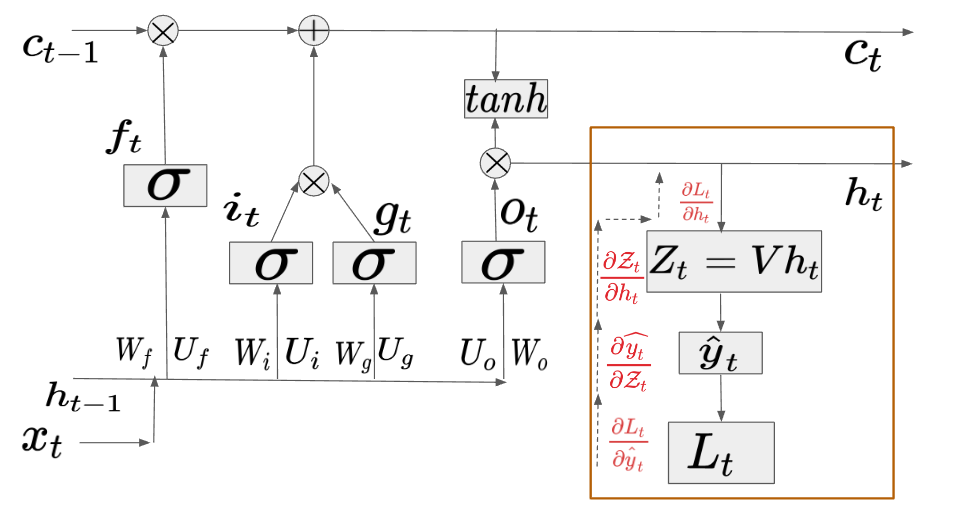

Figure 2. LSTM Backpropagation - Gradients with respect to ${h_t}$





**Derivative of Loss with respect to Cell state $c_t$**

We know,

$\widehat y_t$ = $softmax(V h_t)$

$L_t$ = $y_t log(\widehat y_t)$

$h_t$ = $o_t tanh(c_t)$


$${\frac{\partial {L_t}}{\partial c_t} =  \underbrace{\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t} }_1} \underbrace{\frac{\partial \mathcal{h_t}}{\partial c_t}}_2$$

$\underbrace{\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t} }_1$ , This is actually $d h_t$

$$ \underbrace{\frac{\partial \mathcal{h_t}}{\partial c_t}}_2 = o_t (1 - tanh^2(c_t))$$

*Note: Using the derivative of tan hyperbolic.*


Then, the derivative of loss with respect to $c_t$ is,

$${\frac{\partial {L_t}}{\partial c_t} =   (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t))}$$

Let,
${\frac{\partial {L_t}}{\partial c_t}} $ = $d c_t$


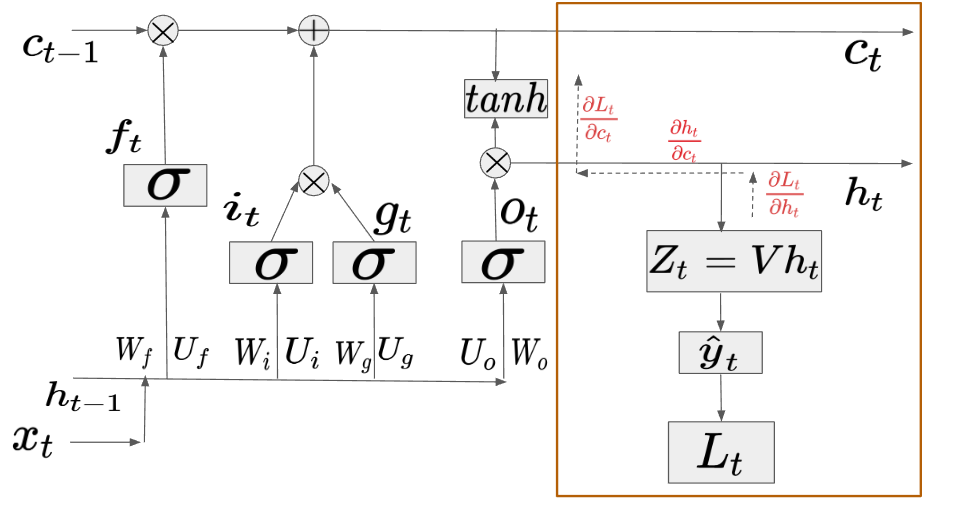

 3. LSTM Backpropagation - Gradients with respect to ${c_t}$



**Derivative of Loss with respect to Candidate state $g_t$**


${\frac{\partial {L_t}}{\partial g_t} =  \underbrace{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}} {\frac{\partial \mathcal{h_t}}{\partial c_t}}}_1} \underbrace{{\frac{\partial \mathcal{c_t}}{\partial g_t}}}_2$

This actually,
$ \underbrace{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}} {\frac{\partial \mathcal{h_t}}{\partial c_t}}}_1$ is $d c_t$

$$\underbrace{{\frac{\partial \mathcal{c_t}}{\partial g_t}}}_2 =   {{\frac{\partial \mathcal{( f_t C_{t-1} + i_t g_t)}}{\partial g_t}}}$$

$$\underbrace{{\frac{\partial \mathcal{c_t}}{\partial g_t}}}_2 =   i_t$$

So, now the derivative of Loss with respect to $g_t$ is,

$${\frac{\partial {L_t}}{\partial g_t} =  (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ i_t} $$


Let, ${\frac{\partial {L_t}}{\partial g_t} }$  =$d g_t$






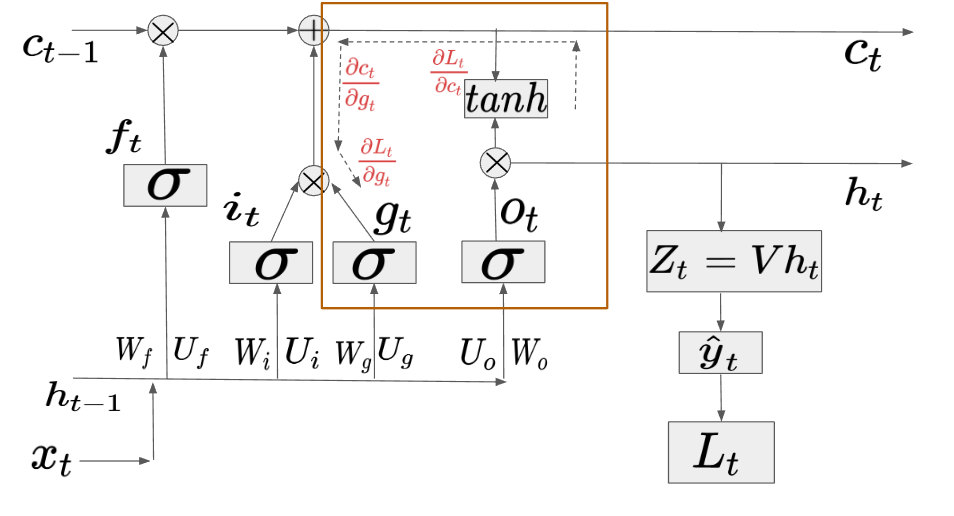

Figure 4. LSTM Backpropagation - Gradients with respect to ${g_t}$



## Gradients of Loss with respect to gates.

In LSTM we have three different gates, Output gate ($o_t$), Input gate ($i_t$), Forget gate ($f_t$)




**Derivative of Loss with respect to Output gate ($o_t$)**

We know,


$\widehat y_t$ = $softmax(V h_t)$

$L_t$ = $y_t log(\widehat y_t)$

$h_t$ = $o_t tanh(c_t)$



$${\frac{\partial {L_t}}{\partial o_t} =  \underbrace{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}_1 \underbrace{{\frac{\partial \mathcal{h_t}}{\partial o_t}}}_2}$$

We have already calcuated $ \underbrace{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}_1$ many times.

$$ \underbrace{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}_1 = (\widehat y_t - y_t) V^T$$

Similarly,

$${{\frac{\partial \mathcal{h_t}}{\partial o_t}}} = {{\frac{\partial \mathcal{o_t tanh(c _t)}}{\partial o_t}}}$$

$${{\frac{\partial \mathcal{h_t}}{\partial o_t}}} = tanh(c_t)$$

 So, the derivaitve of Loss with respect to Output gate is,

$${\frac{\partial {L_t}}{\partial o_t} =  (\widehat y_t - y_t) V^T \circ tanh(c_t)}$$


Let, ${\frac{\partial {L_t}}{\partial o_t}} = d o_t$


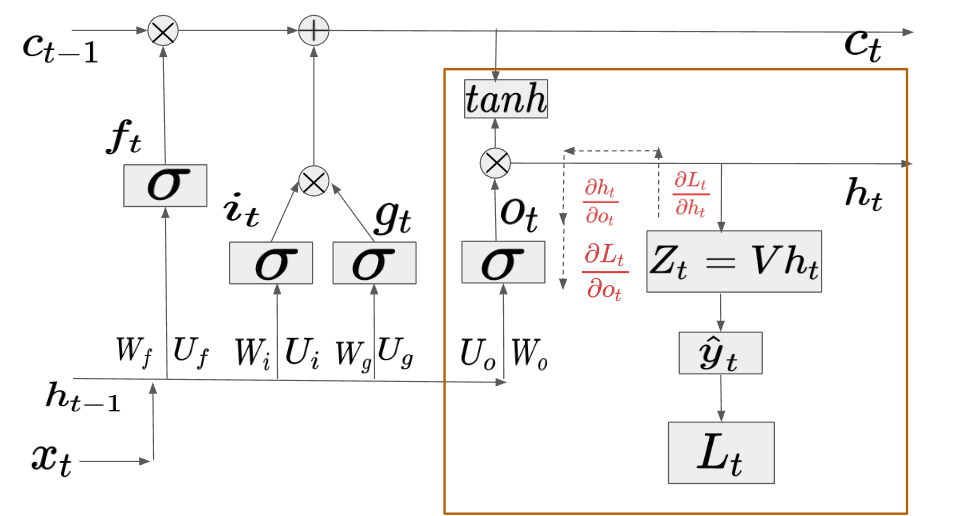


Figure 5. LSTM Backpropagation - Gradients with respect to ${o_t}$


**Derivative of Loss with respect to Input gate ($i_t$)**

We know,


$\widehat y_t$ = $softmax(V h_t)$

$L_t$ = $y_t log(\widehat y_t)$

$h_t$ = $o_t tanh(c_t)$


$c_t$ = $f_t C_{t-1} + i_t g_t$



$${\frac{\partial {L_t}}{\partial i_t} =  \underbrace{{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}{{\frac{\partial \mathcal{h_t}}{\partial c_t}}}}_1} \underbrace{\frac{\partial \mathcal{c_t}}{\partial i_t}}_2$$

Here, this is $\underbrace{{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}{{\frac{\partial \mathcal{h_t}}{\partial c_t}}}}_1$ the derivative of Loss with respect to Cell state ($c_t$) which we have already computed.

Then, the second term,

$$ \underbrace{\frac{\partial \mathcal{c_t}}{\partial i_t}}_2 =  {\frac{\partial \mathcal{(f_t C_{t-1} + i_t g_t)}}{\partial i_t}} = g_t$$

 So, now the derivative of Loss with respect to Input gate $i_t$ is,


$${\frac{\partial {L_t}}{\partial i_t} =  (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t))} \circ g_t$$



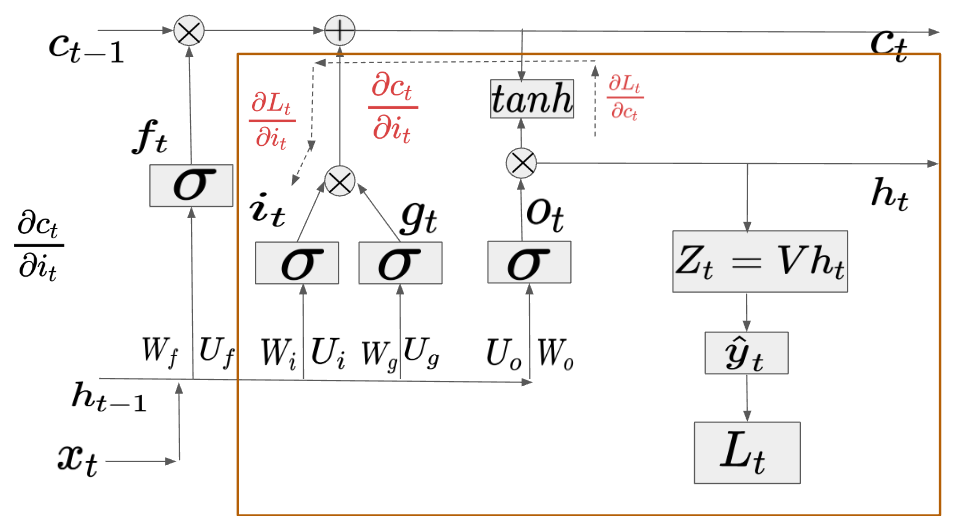



Figure 6. LSTM Backpropagation - Gradients with respect to ${i_t}$






**Derivative of Loss with respect to Forget gate $(f_t$)**

We follow similar approach as we did earlier for input gate and Output gate.

$${\frac{\partial {L_t}}{\partial f_t} =  \underbrace{{ {\frac{\partial {L_t}}{\partial \widehat y_t}  \frac{\partial \mathcal{\widehat y_t}}{\partial h_t}}}{{\frac{\partial \mathcal{h_t}}{\partial c_t}}}}_1} \underbrace{\frac{\partial \mathcal{c_t}}{\partial f_t}}_2$$

The first part is actually the derivative of Loss with respect to Cell state ( $c_t$ )

and,

$$\underbrace{\frac{\partial \mathcal{c_t}}{\partial f_t}}_2 = {\frac{\partial \mathcal{(f_t C_{t-1} + i_t g_t)}}{\partial f_t}} = c_{t-1}$$


$${\frac{\partial {L_t}}{\partial f_t} =   (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) c_{t-1}}$$


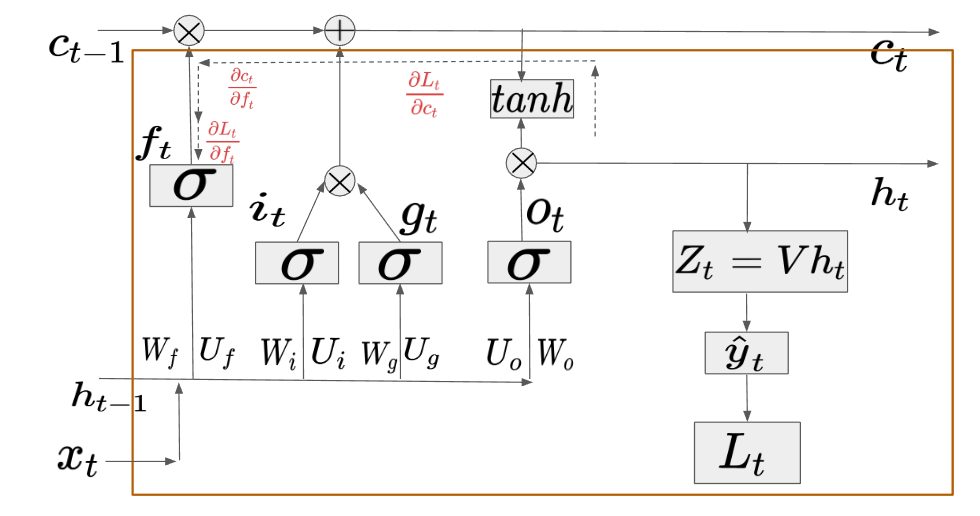


Figure 7. LSTM Backpropagation - Gradients with respect to ${f_t}$







## Gradients of Loss with respect to Weight Paramters.

Till now we have calculatd the derivaties with respect to Gates and States. We would now calcuate derivative of Loss with respect to Weight paramters.


**Derivative of Loss with respect to V**

It is the sum of loss across all time steps i.e

We know,

$\widehat y_t$ = $softmax(V h_t)$

$L_t$ = $y_t log(\widehat y_t)$

Let, $Z_t$ = $V h_t$,  $\widehat y_t$ = $softmax(Z_t)$



$${\frac{\partial {L}}{\partial V} = \sum_{t=1}^T {\frac{\partial {L_t}}{\partial V}}}$$


$${\frac{\partial {L}}{\partial V} = \sum_{t=1}^T \underbrace{{{\frac{\partial {L_t}}{\partial \widehat y_t}}} {\frac{\partial \mathcal{\widehat y_t}}{\partial  Z_t}}}_1} \underbrace{{\frac{\partial \mathcal{Z_t}}{\partial V}}}_2$$

We have already calculated,$\underbrace{{{\frac{\partial \mathcal{L_t}}{\partial \widehat y_t}}} {\frac{\partial \mathcal{\widehat y_t}}{\partial  Z_t}}}_1$ which is $(\widehat y_t - y_t)$

And,

$$\underbrace{{\frac{\partial \mathcal{Z_t}}{\partial V}}}_2 = {{\frac{\partial \mathcal{V h_t}}{\partial V}}} = h_t$$

So, the derivative of Loss with respect to $V$ is,



$${\frac{\partial \mathcal{L}}{\partial V} = \sum_{t=1}^T h_t (\widehat y_t- y_t)}$$








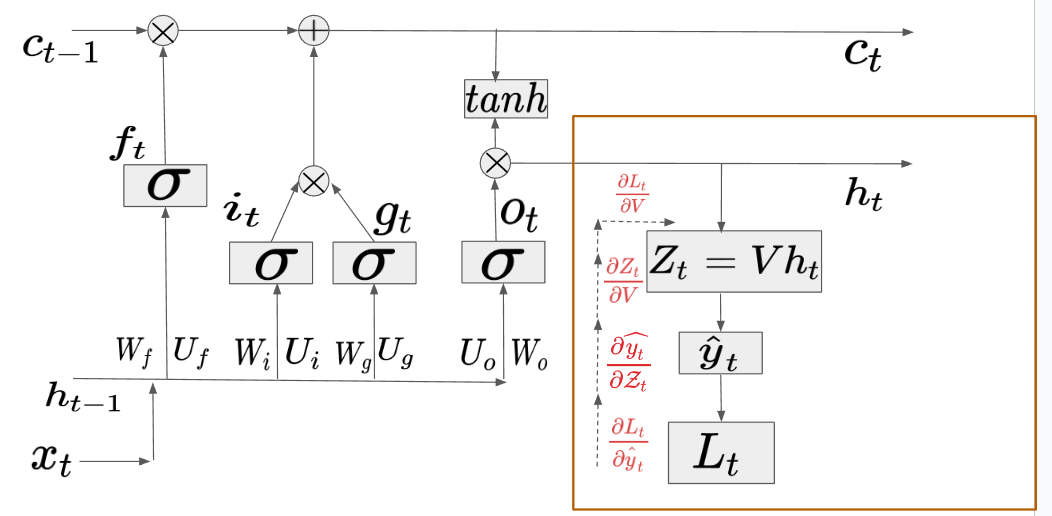



Figure 8. LSTM Backpropagation - Gradients with respect to $V$




**Derivative of Loss with respect to $W_i$**


${\frac{\partial \mathcal{L}}{\partial W_i} = \sum_{t=0}^{T-1} \underbrace{{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}_1 \underbrace{{\frac{\partial \mathcal{ i_t}}{\partial  W_i}}}_2} $

This is $\underbrace{{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}_1$ the derivaitve of Loss with respect to Input gate which we have computed earlier.

And now for the second part,

We know,

$i_t$ = $sigmoid(U_i x_t + W_i  h_{t-1} + b_i)$

$i_t$ = $\sigma(U_i x_t + W_i  h_{t-1} + b_i)$



$\underbrace{{\frac{\partial \mathcal{ i_t}}{\partial  W_i}}}_2 = \sigma(U_i x_t + W_i  h_{t-1} + b_i) [1 - \sigma(U_i x_t + W_i  h_{t-1} + b_i] \circ h_{t-1}$


$\underbrace{{\frac{\partial \mathcal{ i_t}}{\partial  W_i}}}_2 = i_t (1 - i_t ) \circ h_{t-1}$


So, now the derivaitve of Loss with respect to $W_i$ is,


$${\frac{\partial {L}}{\partial W_i} = \sum_{i=0}^{T-1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ g_t}]^T i_t (1 - i_t ) \} \circ h_{t-1} $$










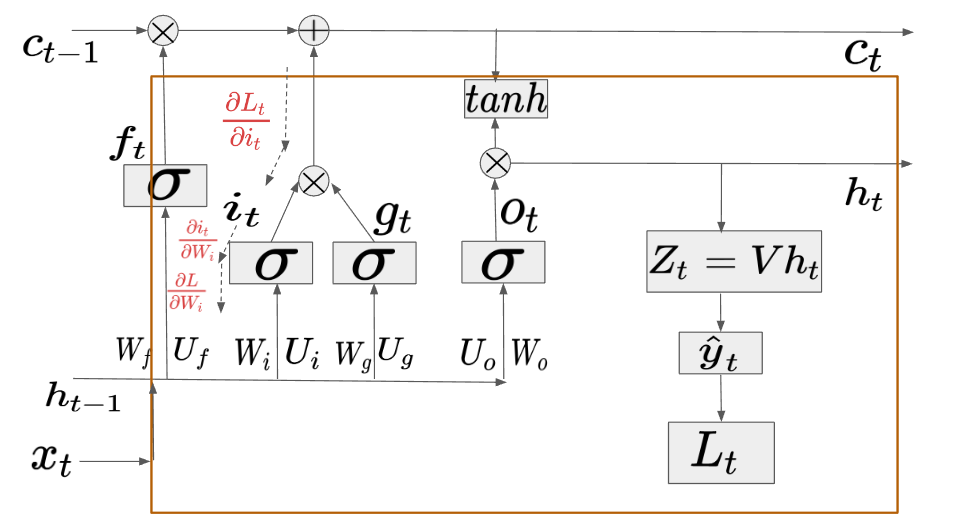
Figure 9. LSTM Backpropagation - Gradients with respect to ${W_i}$






**Derivative of Loss with respect to $W_f$**



${\frac{\partial {L}}{\partial W_f} = \sum_{t=0}^{T-1} \underbrace{{{\frac{\partial {L_t}}{\partial  f_t}}}}_1 \underbrace{{\frac{\partial \mathcal{ f_t}}{\partial  W_f}}}_2} $

This is $\underbrace{{{\frac{\partial {L_t}}{\partial  f_t}}}}_1$ the derivaitve of Loss with respect to Forget gate which we have computed earlier.

And now for the second part,

We know,

$f_t$ = $sigmoid(U_f x_t + W_f  h_{t-1} + b_t)$

$f_t$ = $\sigma(U_f x_t + W_f  h_{t-1} + b_f)$



$\underbrace{{\frac{\partial \mathcal{ f_t}}{\partial  W_f}}}_2 = \sigma(U_f x_t + W_f  h_{t-1} + b_f) [1 - \sigma(U_f x_t + W_f  h_{t-1} + b_i] \circ h_{t-1}$


$\underbrace{{\frac{\partial \mathcal{ f_t}}{\partial  W_f}}}_2 = f_t (1 - f_t ) \circ h_{t-1}$


So, now the derivaitve of Loss with respect to $W_f$ is,


$${\frac{\partial {L}}{\partial W_f} = \sum_{t=0}^{T-1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ c_{t-1}}]^T f_t (1 - f_t ) \} \circ h_{t-1} $$




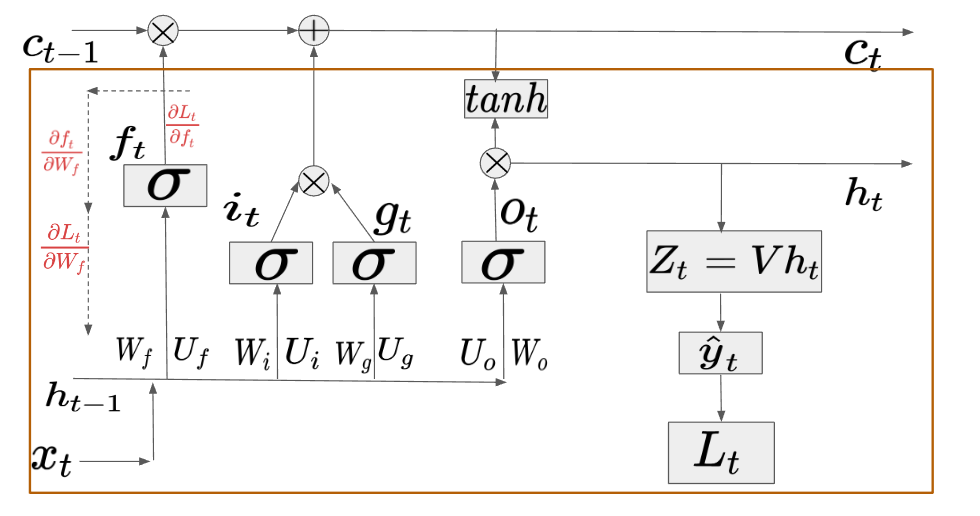







Figure 10. LSTM Backpropagation - Gradients with respect to ${W_f}$






**Derivative of Loss with respect to $W_o$ and $W_g$**

This follows the steps that we carried out earlier for $W_i$ and $W_f$.

we will not write the whole equation. You can verify on your own.


$${\frac{\partial {L}}{\partial W_o} = \sum_{i=0}^{T-1} \{[(\widehat y_t - y_t) V^T  \circ  tanh(c_t)}]^T o_t (1 - o_t ) \} \circ h_{t-1} $$

$${\frac{\partial {L}}{\partial W_g} = \sum_{i=0}^{T-1} \{[(\widehat y_t - y_t) V^T  \circ o_t (1 - tanh^2(c_t))} \circ i_t]^T (1 - g_t^2) \} \circ h_{t-1} $$





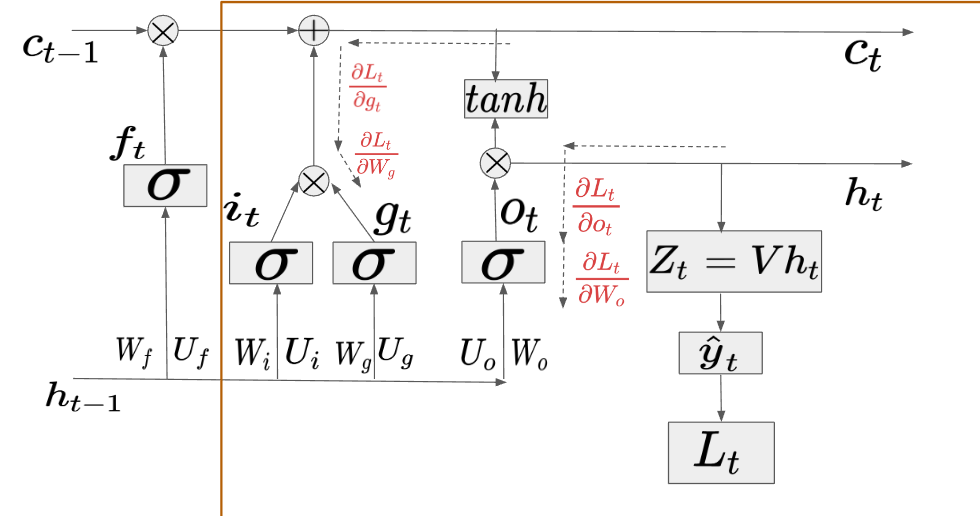


Figure 11. LSTM Backpropagation - Gradients with respect to ${W_o}$ and $W_g$





Now, we move onto calculating gradients with respect to paramter $U$



**Derivative of Loss with respect to $U_i$**

We know,

$i_t$ = $sigmoid(U_i x_t + W_i  h_{t-1} + b_i)$

$i_t$ = $\sigma(U_i x_t + W_i  h_{t-1} + b_i)$


$${\frac{\partial \mathcal{L}}{\partial U_i} = \sum_{t=0}^{T-1} \underbrace{{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}_1 \underbrace{{\frac{\partial \mathcal{ i_t}}{\partial  U_i}}}_2} $$

This, $\underbrace{{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}_1 $ is the derivative of Loss with respect to input gate which we have already computed.

and for the second part,

$$\underbrace{{\frac{\partial \mathcal{ i_t}}{\partial  U_i}}}_2 = {{\frac{\partial \mathcal{ \sigma(U_i x_t + W_i  h_{t-1} + b_i)}}{\partial  U_i}}} =  i_t(1 - i_t) \circ x_t$$

So, the derivative of loss with respect to $U_i$ is,

$${\frac{\partial \mathcal{L}}{\partial U_i} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}  i_t(1 - i_t) \circ x_t }$$







**Derivative of Loss with respect to $U_f$, $U_o$ and $U_g$**


$${\frac{\partial \mathcal{L}}{\partial U_f} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  f_t}}}}  f_t(1 - f_t) \circ x_t }$$

$${\frac{\partial \mathcal{L}}{\partial U_o} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  o_t}}}}  o_t(1 - o_t) \circ x_t }$$


$${\frac{\partial \mathcal{L}}{\partial U_g} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  g_t}}}}  g_t(1 - g_t^2) \circ x_t }$$



# BPTT Calculation

Lets intialize at first  ;


$y_0$ = $[1 \hspace{0.2cm} 0]$, $y_1$ = $[0 \hspace{0.2cm} 1]$

$U_i = [0.95 \hspace {0.2cm} 0.8] $, $W_i = [0.8] $
, $b_i = [0.65] $


$U_f = [0.7 \hspace {0.2cm} 0.45] $ , $W_f = [0.1] $, $b_f = [0.15] $



$U_o = [0.6 \hspace {0.2cm} 0.4] $, $W_o = [0.25] $
, $b_o = [0.1] $


$U_g = [0.45 \hspace {0.2cm} 0.25] $, $W_g = [0.15] $, $b_g = [0.2] $

$V = [0.25 \hspace {0.2cm} 0.45] $


$x_0$ = $[1 \hspace{0.2cm} 0]$, $x_1$ = $[0 \hspace{0.2cm} 1]$






**Forward Propagation at first  time step.**

Candidate gate:

$g_0$ = $tanh(U_g x_0 + W_g h_{-1} + b_g)$

$g_0$ = $tanh([0.45 \hspace{0.2cm} 0.25] [1 \hspace{0.1cm} 0]^T + 0.25 * 0 + 0.2)$

$g_0$ = $tanh( 0.45+ 0 + 0.2)$

$g_0$ = $0.571$




Input gate :

$i_0$ = $sigmoid(U_i x_0 + W_i  h_{-1} + b_i)$

$i_0$ = $sigmoid([0.95 \hspace{0.2cm} 0.8] [1 \hspace{0.2cm} 0 ]^T + 0.8  * 0 + 0.65)$

$i_0$ = $sigmoid(0.95 + 0 + 0.65)$

$i_0$ = $0.83$





Forget gate :

$f_0$ = $ sigmoid(U_f  x_0 + W_f h_{-1} + b_f)$

$f_0$ = $ sigmoid([0.7 \hspace{0.2cm} 0.45] [1 \hspace{0.2cm} 0]^T + [0.1] * 0 + 0.15)$

$f_0$ = $ 0.70 $




Output gate :

$o_0$ = $ sigmoid(U_o  x_0 + W_o h_{-1} + b_o)$

$o_0$ = $ sigmoid( [0.6 \hspace{0.2cm} 0.4]  [1 \hspace{0.2cm} 0]^T + 0.25 *0 + 0.1)$

$o_0$ = $0.66$




Cell State :

$c_0$ = $f_0 C_{-1} + i_0 g_0$

$c_0$ = $0.7 * 0 + 0.83 *  0.57$

$c_0$ = $0.47$



Hidden State :

$h_0$ = $o_0 tanh(c_0)$

$h_0$ = $ 0.66 * tanh(0.47)$

$h_0$ = $0.289$


Output :

$\widehat y_0$ = $softmax(V h_t)$

$\widehat y_0$ = $softmax([0.25 \hspace{0.2cm}0.45] * 0.289)$

$\widehat y_0$ = $softmax([0.07225 \hspace{0.2cm}0.13005])$

$\widehat y_0$ = $[0.4855 \hspace{0.2cm}0.5144]$








**Forward Propagation at Second  time step.**

Candidate gate:

$g_1$ = $tanh(U_g x_1 + W_g h_{0} + b_g)$

$g_1$ = $tanh([0.45 \hspace{0.2cm} 0.25] [0 \hspace{0.1cm} 1]^T + 0.25 * 0.289 + 0.2)$

$g_1$ = $tanh( 0.52225)$

$g_1$ = $0.4794$




Input gate :

$i_1$ = $sigmoid(U_i x_1 + W_i  h_{0} + b_i)$

$i_1$ = $sigmoid([0.95 \hspace{0.2cm} 0.8] [0 \hspace{0.2cm} 1 ]^T + 0.8  * 0.289 + 0.65)$

$i_1$ = $sigmoid(1.6812)$

$i_1$ = $0.84$





Forget gate :

$f_1$ = $ sigmoid(U_f  x_1 + W_f h_{0} + b_f)$

$f_1$ = $ sigmoid([0.7 \hspace{0.2cm} 0.45] [0 \hspace{0.2cm} 1]^T + [0.1] * 0.289 + 0.15)$

$f_1$ = $ 0.6522 $





Output gate :

$o_1$ = $ sigmoid(U_o  x_1 + W_o h_{0} + b_o)$

$o_1$ = $ sigmoid( [0.6 \hspace{0.2cm} 0.4]  [0 \hspace{0.2cm} 1]^T + 0.25 * 0.289 + 0.1)$

$o_1$ = $0.6392$




Cell State :

$c_1$ = $f_1 c_{0} + i_1 g_1$

$c_1$ = $0.6522 * 0.47 + 0.84 *  0.47$

$c_1$ = $0.701$



Hidden State :

$h_1$ = $o_1 tanh(c_1)$

$h_1$ = $ 0.6392 * tanh(0.701)$

$h_1$ = $0.3867$



Output :

$\widehat y_1$ = $softmax(V h_1)$

$\widehat y_1$ = $softmax([0.25 \hspace{0.2cm}0.45] * 0.3867)$

$\widehat y_1$ = $softmax([0.096675 \hspace{0.2cm}0.174015])$

$\widehat y_1$ = $[0.4806 \hspace{0.2cm}0.5193]$








## Backpropagation

**Gradient of Loss with respect to $V$ :**


${\frac{\partial \mathcal{L}}{\partial V} = \sum_{i=1}^T h_i^T (\widehat y_i- y_i)}$

${\frac{\partial \mathcal{L}}{\partial V} = \sum_{i=0}^1 h_i^T (\widehat y_i- y_i)}$

${\frac{\partial \mathcal{L}}{\partial V} =  h_0^T (\widehat y_0- y_0)} +  h_1^T (\widehat y_1- y_1)$

${\frac{\partial \mathcal{L}}{\partial V} =  0.289 * ([0.4855 \hspace{0.2cm}0.5144]- [1 \hspace{0.2cm}0])} +  0.3867 ( [0.4806 \hspace{0.2cm}0.5193] -  [0 \hspace{0.2cm} 1]$

${\frac{\partial \mathcal{L}}{\partial V} =  0.289 * ([-0.5145 \hspace{0.2cm}0.5144]
)} +  0.3867 * ( [0.4806 \hspace{0.2cm}0.4807] $



${\frac{\partial \mathcal{L}}{\partial V} =  [-0.1486 \hspace{0.2cm}0.1486]
} +   [0.1858 \hspace{0.2cm}0.1858] $


${\frac{\partial \mathcal{L}}{\partial V} =  [0.0372 \hspace{0.2cm}0.3344]
}  $


**Gradient of Loss with respect to $W_i$**

${\frac{\partial \mathcal{L}}{\partial W_i} = \sum_{t=0}^{T-1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ g_t}]^T i_t (1 - i_t ) \} \circ h_{t-1} $

$ $

${\frac{\partial \mathcal{L}}{\partial W_i} = \sum_{t=0}^{1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ g_t}]^T i_t (1 - i_t ) \} \circ h_{t-1} $

$ $

${\frac{\partial \mathcal{L}}{\partial W_i}} = \{ [( \widehat y_0 - y_0) V^T \circ o_0(1 - tanh^2(c_0)) \circ g_0]^T * i_0(1 - i_0) \circ h_{-1}  \} + \{ [( \widehat y_1 - y_1) V^T \circ o_1(1 - tanh^2(c_1)) \circ g_1]^T * i_1(1 - i_1) \circ h_{0}  \}$

${\frac{\partial \mathcal{L}}{\partial W_i}} = \{ [( [0.4855 \hspace{0.2cm}0.5144] - [1 \hspace{0.2cm}0]) [ 0.25 \hspace {0.2cm} 0.45]^T \circ 0.66 (1 - tanh^2(0.47)) \circ 0.571]^T * 0.83(1 - 0.83) \circ 0  \} + \{ [( \widehat y_1 - y_1) V^T \circ o_1(1 - tanh^2(c_1)) \circ g_1]^T * i_1(1 - i_1) \circ h_{0}  \}$


${\frac{\partial \mathcal{L}}{\partial W_i}} = 0+\{ [( [0.4806 \hspace{0.2cm}0.5193] - [0 \hspace{0.2cm} 1]) [0.25 \hspace{0.2cm}0.45]^T \circ 0.6392(1 - tanh^2(0.701)) \circ 0.4794]^T * 0.84(1 - 0.84) \circ 0.289  \}$


${\frac{\partial \mathcal{L}}{\partial W_i}} =  \{ [( [0.4806 \hspace{0.2cm}0.4807] ) [0.25 \hspace{0.2cm}0.45]^T \circ 0.6392(0.6339) \circ 0.4794]^T * 0.1344 \circ 0.289  \}$

${\frac{\partial \mathcal{L}}{\partial W_i}} = 0.002538$



**Gradient of Loss with respect to $W_f$**

${\frac{\partial \mathcal{L}}{\partial W_f} = \sum_{t=0}^{T-1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ c_{t-1}}]^T f_t (1 - f_t ) \} \circ h_{t-1} $

$ $

${\frac{\partial \mathcal{L}}{\partial W_f} = \sum_{t=0}^{1} \{[(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ c_{t-1}}]^T f_t (1 - f_t ) \} \circ h_{t-1} $

$ $



${\frac{\partial \mathcal{L}}{\partial W_i}} = \{ [( \widehat y_0 - y_0) V^T \circ o_0(1 - tanh^2(c_0)) \circ c_{-1}]^T * f_0(1 - f_0) \circ h_{-1}  \} + \{ [( \widehat y_1 - y_1) V^T \circ o_1(1 - tanh^2(c_1)) \circ c_0]^T * f_1(1 - f_1) \circ h_{0}  \}$



${\frac{\partial \mathcal{L}}{\partial W_i}} = 0 + \{ [( [0.4806 \hspace{0.2cm}0.5193] - [0 \hspace{0.2cm} 1]) [0.25 \hspace{0.2cm}0.45]^T \circ 0.6392(1 - tanh^2(0.701)) \circ 0.47]^T * 0.6522(1 - 0.6522) \circ 0.289  \}$



${\frac{\partial \mathcal{L}}{\partial W_i}} = 0 + \{ 0.33642 \circ 0.6392(1 - tanh^2(0.701)) \circ 0.47]^T * 0.6522(1 - 0.6522) \circ 0.289  \}$



${\frac{\partial \mathcal{L}}{\partial W_i}} = 0.00419$


**Gradient of Loss with respect to $W_o$ and $W_g$**

Similarly, calculating gradients for $W_o$ and $W_g$, we get,

${\frac{\partial \mathcal{L}}{\partial W_o} = \sum_{i=0}^{T-1} \{[(\widehat y_t - y_t) V^T  \circ (1 - tanh(c_t))}]^T o_t (1 - o_t ) \} \circ h_{t-1} $

$ $
${\frac{\partial \mathcal{L}}{\partial W_o}} =0.00885 $




${\frac{\partial \mathcal{L}}{\partial W_g} = \sum_{i=0}^{T-1} \{[(\widehat y_t - y_t) V^T  \circ o_t (1 - tanh^2(c_t))} \circ i_t]^T (1 - g_t^2) \} \circ h_{t-1} $

$ $
${\frac{\partial \mathcal{L}}{\partial W_g} }= 0.025 $

**Gradient of Loss with respect to $U_i$**



${\frac{\partial \mathcal{L}}{\partial U_i} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  i_t}}}}  i_t(1 - i_t) \circ x_t }$


${\frac{\partial \mathcal{L}}{\partial i_t} =  \sum_{t=0}^{T-1} (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t))} \circ g_t$

${\frac{\partial \mathcal{L}}{\partial U_i} =    \sum_{t=0}^{T-1} {(\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t))} \circ g_t  ( i_t(1 - i_t) \circ x_t })$


${\frac{\partial \mathcal{L}}{\partial U_i} =   0.0041266 * [1 \hspace{0.2cm} 0 ] + (-0.0025088) * [0 \hspace{0.2cm} 1]}$

${\frac{\partial \mathcal{L}}{\partial U_i} =   [ 0.0041266  \hspace{0.2cm} 0 ] + [0 \hspace{0.2cm} -0.0025088]}$

${\frac{\partial \mathcal{L}}{\partial U_i} =   [ 0.0041266  \hspace{0.2cm} -0.0025088 ] }$





**Gradient of Loss with respect to $U_f$**



${\frac{\partial \mathcal{L}}{\partial U_f} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  f_t}}}}  f_t(1 - f_t) \circ x_t }$

${\frac{\partial \mathcal{L}}{\partial U_f} = \sum_{t=0}^{T-1}  (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) c_{t-1}  f_t(1 - f_t) \circ x_t }$

*Since, $c_{-1} = 0$*

${\frac{\partial \mathcal{L}}{\partial U_f} = 0+ (\widehat y_1 - y_1) V^T \circ  o_1 (1 - tanh^2(c_1)) c_{0}  f_1(1 - f_1) \circ x_1 }$


${\frac{\partial \mathcal{L}}{\partial U_f} = [0 \hspace{0.2cm} -0.00415]}$




**Gradients of Loss with respect to $U_O$ and $U_g$**

${\frac{\partial \mathcal{L}}{\partial U_o} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  o_t}}}}  o_t(1 - o_t) \circ x_t }$


${\frac{\partial \mathcal{L}}{\partial U_o} = \sum_{t=0}^{T-1} (\widehat y_t - y_t) V^T \circ tanh(c_t)  o_t(1 - o_t) \circ x_t }$



${\frac{\partial \mathcal{L}}{\partial U_o} = (\widehat y_0 - y_0) V^T \circ tanh(c_0)  o_0(1 - o_0) \circ x_0 + (\widehat y_1 - y_1) V^T \circ tanh(c_1)  o_1(1 - o_1) \circ x_1 }$

${\frac{\partial \mathcal{L}}{\partial U_o} = 0.0648 * [1 \hspace{0.2cm} 0]+ (-0.001288) * [0 \hspace{0.1cm} 1]}$


${\frac{\partial \mathcal{L}}{\partial U_o} = [0.0648 \hspace{0.2cm} 0] + [0 \hspace{0.1cm} -0.001288]}$


${\frac{\partial \mathcal{L}}{\partial U_o} = [0.0648 \hspace{0.2cm} -0.001288]}$




${\frac{\partial \mathcal{L}}{\partial U_g} = \sum_{t=0}^{T-1} {{{\frac{\partial \mathcal{L_t}}{\partial  g_t}}}}  g_t(1 - g_t^2) \circ x_t }$

${\frac{\partial \mathcal{L}}{\partial U_g} = \sum_{t=0}^{T-1} (\widehat y_t - y_t) V^T \circ  o_t (1 - tanh^2(c_t)) \circ i_t  g_t(1 - g_t^2) \circ x_t }$

${\frac{\partial \mathcal{L}}{\partial U_g} =  (\widehat y_0 - y_1) V^T \circ  o_0 (1 - tanh^2(c_0)) \circ i_0  g_0(1 - g_0^2) \circ x_0 + (\widehat y_1 - y_1) V^T \circ  o_1 (1 - tanh^2(c_1)) \circ i_1  g_1(1 - g_1^2) \circ x_1}$

${\frac{\partial \mathcal{L}}{\partial U_g} =  0.01622 * [1 \hspace{0.2cm} 0] + (-0.0120) * [0 \hspace{0.2cm} 1]}$


${\frac{\partial \mathcal{L}}{\partial U_g} =  [0.01622 \hspace{0.2cm} -0.0120]}$


**Weight Update**



$W_i = W_i - \alpha * {\frac{\partial \mathcal{L}}{\partial W_i}}$

$W_i = 0.8 - ( 0.0001 *0.002538) $

$W_i = 0.8 - ( 0.1 *0.002538) $

$W_i = 0.7997$

Similarly, update the weights for $W_f$, $W_o$, $W_g$


$U_i = U_i - \alpha * {\frac{\partial \mathcal{L}}{\partial U_i}}$


$U_i = [0.95 \hspace{0.2cm} 0.8] - 0.1 *    [ 0.0041266  \hspace{0.2cm} -0.0025088 ]$

$U_i = [0.95 \hspace{0.2cm} 0.8] - [ 0.00041266  \hspace{0.2cm} -0.00025088 ]$

$U_i = [0.9495 \hspace{0.2cm} 0.7997] $

Similarly, update the weights for  $U_f$, $U_o$, $U_i$ and $U_g$





## Key takeaways

- There are different gates and states in LSTM that prevents from gradients to vanish.


- LSTM Solves the problem of Vanishing gradients.